# README Visualizations

This notebook generates explanatory visualizations for the
`municipal-water-demand-forecasting` README.

The expanding-window validation animation is constructed from the same
`config/modeling.yml` settings and `src.evaluation.time_splits` utilities used
by the modeling analysis.

In [1]:
from pathlib import Path
import os
import subprocess
import sys


REPOSITORY_NAME = "municipal-water-demand-forecasting"
REPOSITORY_URL = (
    "https://github.com/fureyc/"
    "municipal-water-demand-forecasting.git"
)

REPO_ROOT = Path("/content") / REPOSITORY_NAME


if not REPO_ROOT.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(REPO_ROOT),
        ],
        check=True,
    )
else:
    print(f"Repository already available: {REPO_ROOT}")

os.chdir(REPO_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repository root:", REPO_ROOT)
print("Working directory:", Path.cwd())

Repository root: /content/municipal-water-demand-forecasting
Working directory: /content/municipal-water-demand-forecasting


In [2]:
import shutil

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

from matplotlib.patches import Patch, Rectangle
from PIL import Image
from IPython.display import display

from src.evaluation.time_splits import (
    build_expanding_window_splits,
    get_final_holdout,
    load_modeling_config,
    summarize_splits,
    validate_holdout_isolation,
)

In [22]:
CONFIG_PATH = REPO_ROOT / "config" / "modeling.yml"

DATA_PATH = (
    REPO_ROOT
    / "data"
    / "processed"
    / "fort_collins_daily_water_weather.csv"
)


config = load_modeling_config(CONFIG_PATH)

date_column = config["forecast"]["date_column"]

daily = pd.read_csv(
    DATA_PATH,
    parse_dates=[date_column],
)

daily = (
    daily
    .sort_values(date_column)
    .reset_index(drop=True)
)


splits = build_expanding_window_splits(
    daily,
    config,
)

holdout = get_final_holdout(
    daily,
    config,
)

validate_holdout_isolation(
    splits,
    holdout,
)


split_summary = summarize_splits(splits)

display(split_summary)

print("Validation folds:", len(splits))
print(
    "Final holdout:",
    holdout.start.date(),
    "through",
    holdout.end.date(),
)

,fold,train_start,train_end,n_train,validation_start,validation_end,n_validation
0,1,2020-01-01,2022-12-31,1096,2023-01-01,2023-03-31,90
1,2,2020-01-01,2023-03-31,1186,2023-04-01,2023-06-30,91
2,3,2020-01-01,2023-06-30,1277,2023-07-01,2023-09-30,92
3,4,2020-01-01,2023-09-30,1369,2023-10-01,2023-12-31,92
4,5,2020-01-01,2023-12-31,1461,2024-01-01,2024-03-31,91
5,6,2020-01-01,2024-03-31,1552,2024-04-01,2024-06-30,91
6,7,2020-01-01,2024-06-30,1643,2024-07-01,2024-09-30,92
7,8,2020-01-01,2024-09-30,1735,2024-10-01,2024-12-31,92
8,9,2020-01-01,2024-12-31,1827,2025-01-01,2025-03-31,90


Validation folds: 9
Final holdout: 2025-04-01 through 2026-03-31


In [23]:
FIGURE_DIR = REPO_ROOT / "reports" / "figures"

FRAME_DIR = Path("/content/expanding_window_frames")

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

if FRAME_DIR.exists():
    shutil.rmtree(FRAME_DIR)

FRAME_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


# Figure dimensions
FIGSIZE = (12, 3)
DPI = 150


# Color scheme
TRAIN_COLOR = "tab:blue"
VALIDATION_COLOR = "tab:orange"
FUTURE_COLOR = "0.85"
HOLDOUT_COLOR = "tab:red"


# Timeline geometry
BAR_Y = 0.43
BAR_HEIGHT = 0.34


print("Figure directory:", FIGURE_DIR)
print("Temporary frame directory:", FRAME_DIR)

Figure directory: /content/municipal-water-demand-forecasting/reports/figures
Temporary frame directory: /content/expanding_window_frames


In [24]:
def quarter_label(date):
    """Convert a timestamp to a label such as '2023 Q1'."""
    quarter = ((date.month - 1) // 3) + 1
    return f"{date.year} Q{quarter}"

In [25]:
def draw_validation_frame(
    current_fold=None,
    final_frame=False,
    output_path=None,
):
    """
    Draw one frame of the expanding-window validation animation.

    Parameters
    ----------
    current_fold : int or None
        Zero-based index of the active validation fold.
        Use 0 through 8 for the nine validation frames.

    final_frame : bool
        If True, show the final model-fit stage after validation
        is complete.

    output_path : pathlib.Path or None
        Optional path used to save the frame.
    """

    fig, ax = plt.subplots(
        figsize=FIGSIZE,
        dpi=DPI,
    )

    # ---------------------------------------------------------
    # Title and subtitle
    # ---------------------------------------------------------

    fig.suptitle(
        "Expanding-window rolling validation",
        fontsize=16,
        fontweight="semibold",
        y=0.95,
    )

    if final_frame:
        subtitle = (
            "Final model fit — Train through 2025-03-31, "
            "then evaluate on holdout"
        )
    else:
        active_split = splits[current_fold]

        subtitle = (
            f"Fold {active_split.fold} of {len(splits)} "
            f"— Validation: "
            f"{quarter_label(active_split.validation_start)}"
        )

    ax.set_title(
        subtitle,
        fontsize=12.5,
        pad=14,
    )

    # ---------------------------------------------------------
    # Helper for drawing one dated rectangle
    # ---------------------------------------------------------

    def add_period(start, end, color):
        start_num = mdates.date2num(start)

        # Add one day because the project date ranges
        # are inclusive at both ends.
        end_exclusive = end + pd.Timedelta(days=1)

        width = (
            mdates.date2num(end_exclusive)
            - start_num
        )

        rectangle = Rectangle(
            (start_num, BAR_Y),
            width,
            BAR_HEIGHT,
            facecolor=color,
            edgecolor="white",
            linewidth=1.5,
        )

        ax.add_patch(rectangle)

    # ---------------------------------------------------------
    # Initial development period
    # ---------------------------------------------------------

    initial_start = splits[0].train_start
    initial_end = splits[0].train_end

    add_period(
        initial_start,
        initial_end,
        TRAIN_COLOR,
    )

    # ---------------------------------------------------------
    # Nine rolling-validation quarters
    # ---------------------------------------------------------

    for index, split in enumerate(splits):

        if final_frame:
            color = TRAIN_COLOR

        elif index < current_fold:
            # Previous validation folds have now become
            # part of the expanding training history.
            color = TRAIN_COLOR

        elif index == current_fold:
            color = VALIDATION_COLOR

        else:
            color = FUTURE_COLOR

        add_period(
            split.validation_start,
            split.validation_end,
            color,
        )

    # ---------------------------------------------------------
    # Final untouched holdout
    # ---------------------------------------------------------

    add_period(
        holdout.start,
        holdout.end,
        HOLDOUT_COLOR,
    )

    # ---------------------------------------------------------
    # Axis formatting
    # ---------------------------------------------------------

    timeline_start = initial_start
    timeline_end = holdout.end + pd.Timedelta(days=1)

    ax.set_xlim(
        timeline_start,
        timeline_end,
    )

    ax.set_ylim(0, 1)

    ax.xaxis.set_major_locator(
        mdates.YearLocator()
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter("%Y")
    )

    ax.tick_params(
        axis="x",
        labelsize=10,
        length=0,
        pad=8,
    )

    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(False)

    # ---------------------------------------------------------
    # Legend
    # ---------------------------------------------------------

    legend_handles = [
        Patch(
            facecolor=TRAIN_COLOR,
            label="Training",
        ),
        Patch(
            facecolor=VALIDATION_COLOR,
            label="Current validation",
        ),
        Patch(
            facecolor=FUTURE_COLOR,
            label="Future validation",
        ),
        Patch(
            facecolor=HOLDOUT_COLOR,
            label="Final holdout",
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=4,
        frameon=False,
        fontsize=10,
        handlelength=1.4,
        columnspacing=2.2,
    )

    fig.subplots_adjust(
        left=0.055,
        right=0.985,
        top=0.68,
        bottom=0.31,
    )

    if output_path is not None:
        fig.savefig(
            output_path,
            dpi=DPI,
            facecolor="white",
        )

    return fig, ax

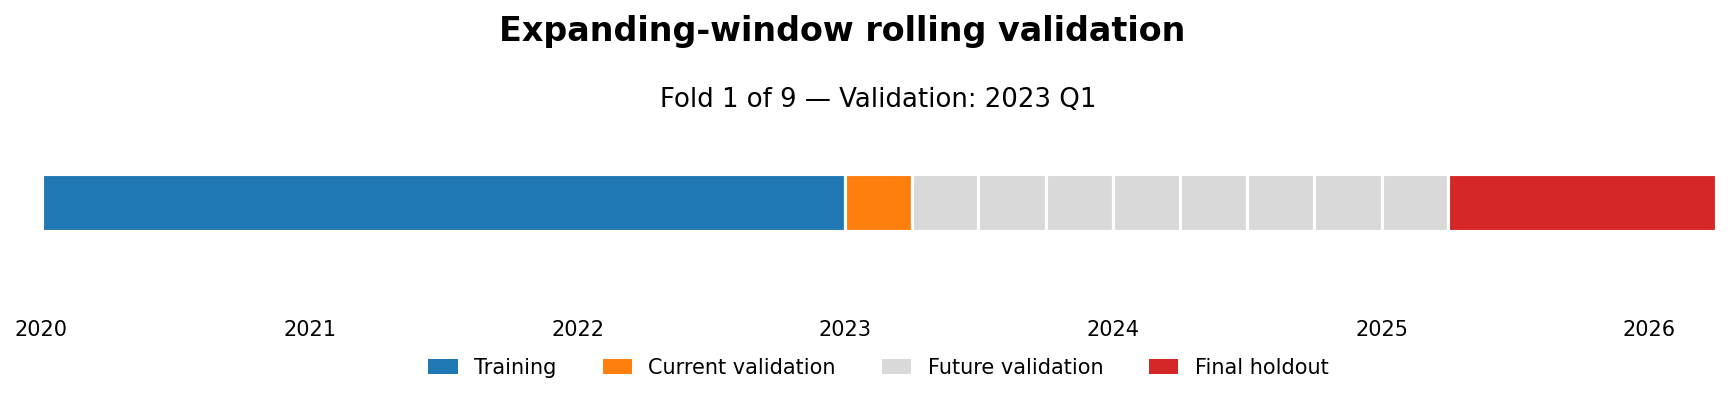

In [26]:
fig, ax = draw_validation_frame(
    current_fold=0,
    final_frame=False,
)

plt.show()

In [27]:
PNG_PATH = (
    FIGURE_DIR
    / "expanding_window_validation.png"
)


fig, ax = draw_validation_frame(
    current_fold=0,
    final_frame=False,
    output_path=PNG_PATH,
)

plt.close(fig)

print("Saved:", PNG_PATH)

Saved: /content/municipal-water-demand-forecasting/reports/figures/expanding_window_validation.png


In [28]:
frame_paths = []


# Frames 1–9: rolling validation
for fold_index in range(len(splits)):

    frame_path = (
        FRAME_DIR
        / f"frame_{fold_index + 1:02d}.png"
    )

    fig, ax = draw_validation_frame(
        current_fold=fold_index,
        final_frame=False,
        output_path=frame_path,
    )

    plt.close(fig)

    frame_paths.append(frame_path)


# Frame 10: final model fit
final_frame_path = (
    FRAME_DIR
    / "frame_10.png"
)

fig, ax = draw_validation_frame(
    final_frame=True,
    output_path=final_frame_path,
)

plt.close(fig)

frame_paths.append(final_frame_path)


print("Frames created:", len(frame_paths))

for path in frame_paths:
    print(path.name)

Frames created: 10
frame_01.png
frame_02.png
frame_03.png
frame_04.png
frame_05.png
frame_06.png
frame_07.png
frame_08.png
frame_09.png
frame_10.png


In [29]:
GIF_PATH = (
    FIGURE_DIR
    / "expanding_window_validation.gif"
)


images = [
    Image.open(path).convert("RGBA")
    for path in frame_paths
]


# Frames 1–9 remain visible for 0.9 seconds.
# The final frame remains visible for 1.8 seconds.
durations = (
    [900] * 9
    + [1800]
)


images[0].save(
    GIF_PATH,
    save_all=True,
    append_images=images[1:],
    duration=durations,
    loop=0,
    disposal=2,
)


for image in images:
    image.close()


print("Saved:", GIF_PATH)

Saved: /content/municipal-water-demand-forecasting/reports/figures/expanding_window_validation.gif


In [30]:
with Image.open(GIF_PATH) as gif:
    print("GIF dimensions:", gif.size)
    print("Number of frames:", gif.n_frames)

print(
    "File size:",
    f"{GIF_PATH.stat().st_size / 1024**2:.2f} MB",
)

GIF dimensions: (1800, 450)
Number of frames: 10
File size: 0.15 MB


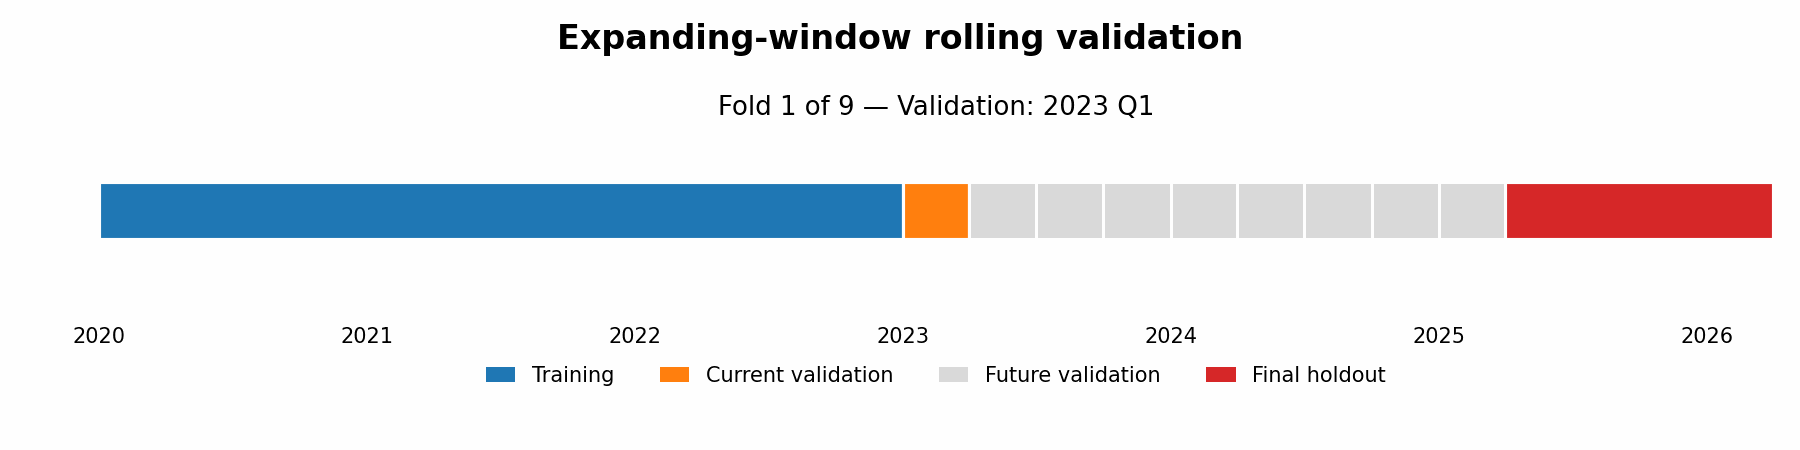

In [31]:
from IPython.display import Image as DisplayImage


display(
    DisplayImage(
        filename=str(GIF_PATH)
    )
)

In [32]:
from google.colab import files


files.download(
    str(PNG_PATH)
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
files.download(
    str(GIF_PATH)
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final holdout model comparison

This figure summarizes mean absolute error on the untouched final holdout.
Metrics are read from the exported modeling results rather than recomputed here.

In [34]:
HOLDOUT_METRICS_PATH = (
    REPO_ROOT
    / "reports"
    / "final_holdout_metrics.csv"
)

holdout_metrics = pd.read_csv(
    HOLDOUT_METRICS_PATH
)

display(
    holdout_metrics[
        ["model", "mae"]
    ]
)

,model,mae
0,Previous-day naïve,1.284438
1,Ridge B,0.993722
2,XGBoost B,0.876285


In [35]:
MODEL_LABELS = {
    "Previous-day naïve": "Previous-day persistence",
    "Ridge B": "Ridge",
    "XGBoost B": "XGBoost",
}

MODEL_COLORS = {
    "Previous-day naïve": "0.65",
    "Ridge B": "tab:green",
    "XGBoost B": "tab:orange",
}


plot_metrics = (
    holdout_metrics
    .loc[
        holdout_metrics["model"].isin(MODEL_LABELS),
        ["model", "mae"]
    ]
    .copy()
)

plot_metrics["display_name"] = (
    plot_metrics["model"]
    .map(MODEL_LABELS)
)

plot_metrics["color"] = (
    plot_metrics["model"]
    .map(MODEL_COLORS)
)

display(plot_metrics)

,model,mae,display_name,color
0,Previous-day naïve,1.284438,Previous-day persistence,0.65
1,Ridge B,0.993722,Ridge,tab:green
2,XGBoost B,0.876285,XGBoost,tab:orange


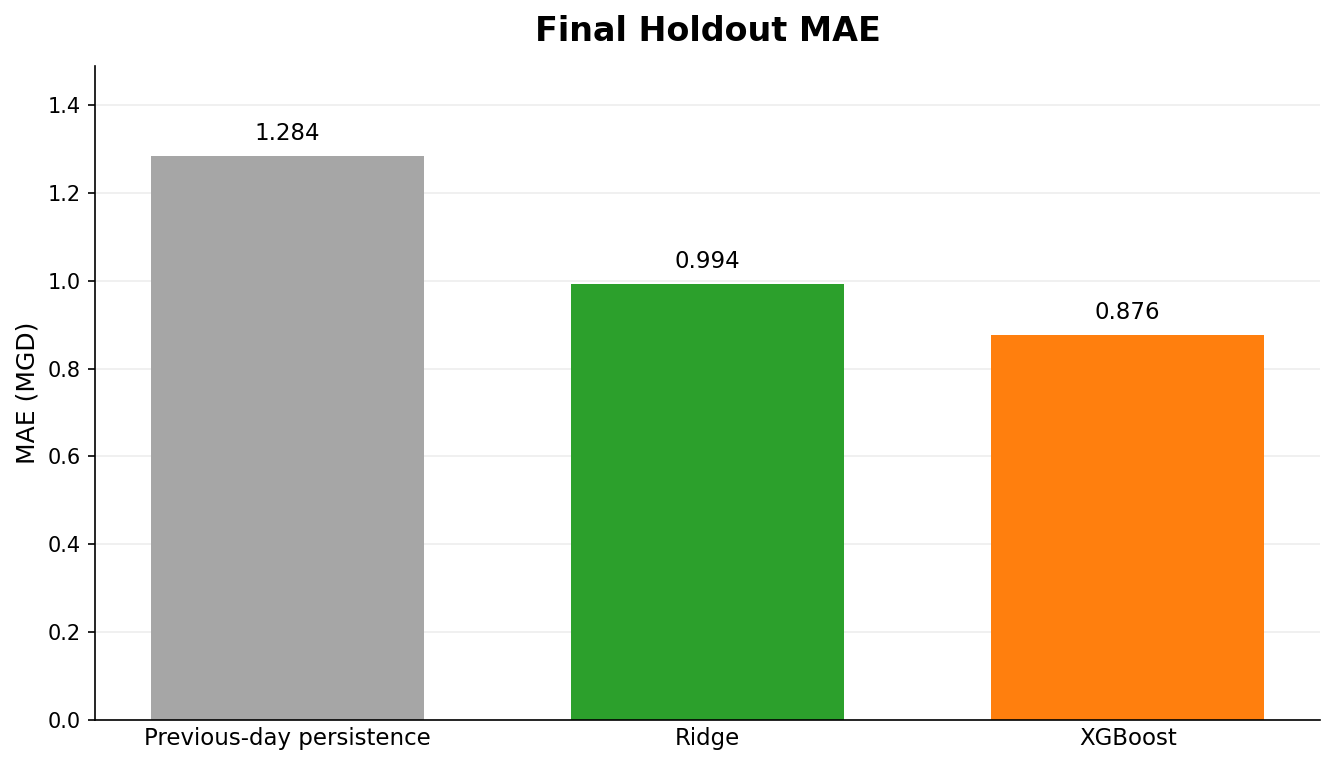

Saved: /content/municipal-water-demand-forecasting/reports/figures/final_holdout_model_comparison.png


In [36]:
MAE_FIGURE_PATH = (
    FIGURE_DIR
    / "final_holdout_model_comparison.png"
)


fig, ax = plt.subplots(
    figsize=(9, 5.2),
    dpi=150,
)


bars = ax.bar(
    plot_metrics["display_name"],
    plot_metrics["mae"],
    color=plot_metrics["color"],
    width=0.65,
)


# ---------------------------------------------------------
# Value labels
# ---------------------------------------------------------

for bar, value in zip(
    bars,
    plot_metrics["mae"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.025,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )


# ---------------------------------------------------------
# Titles and labels
# ---------------------------------------------------------

ax.set_title(
    "Final Holdout MAE",
    fontsize=16,
    fontweight="semibold",
    pad=12,
)

ax.set_ylabel(
    "MAE (MGD)",
    fontsize=12,
)

ax.set_xlabel("")


# ---------------------------------------------------------
# Axis formatting
# ---------------------------------------------------------

ax.set_ylim(
    0,
    plot_metrics["mae"].max() * 1.16,
)

ax.tick_params(
    axis="x",
    labelsize=11,
    length=0,
)

ax.tick_params(
    axis="y",
    labelsize=10,
)


# Light horizontal reference lines only
ax.grid(
    axis="y",
    alpha=0.22,
)

ax.set_axisbelow(True)


# Remove unnecessary frame lines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


fig.tight_layout()


fig.savefig(
    MAE_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", MAE_FIGURE_PATH)

## Final holdout: observed versus predicted demand

This figure shows observed daily municipal water demand during the final
holdout year together with predictions from the final Ridge and XGBoost
models. The plot is rebuilt directly from the exported holdout predictions.

In [37]:
HOLDOUT_PREDICTIONS_PATH = (
    REPO_ROOT
    / "reports"
    / "final_holdout_predictions.csv"
)

holdout_predictions = pd.read_csv(
    HOLDOUT_PREDICTIONS_PATH,
    parse_dates=["date"],
)

display(
    holdout_predictions[
        ["date", "y_true", "ridge_prediction", "xgb_prediction"]
    ].head()
)

,date,y_true,ridge_prediction,xgb_prediction
0,2025-04-01,14.44,13.774630,14.737638
1,2025-04-02,13.29,14.621388,14.730327
2,2025-04-03,13.74,13.159242,14.049987
3,2025-04-04,13.74,13.185717,13.719649
4,2025-04-05,13.55,12.913625,13.718884


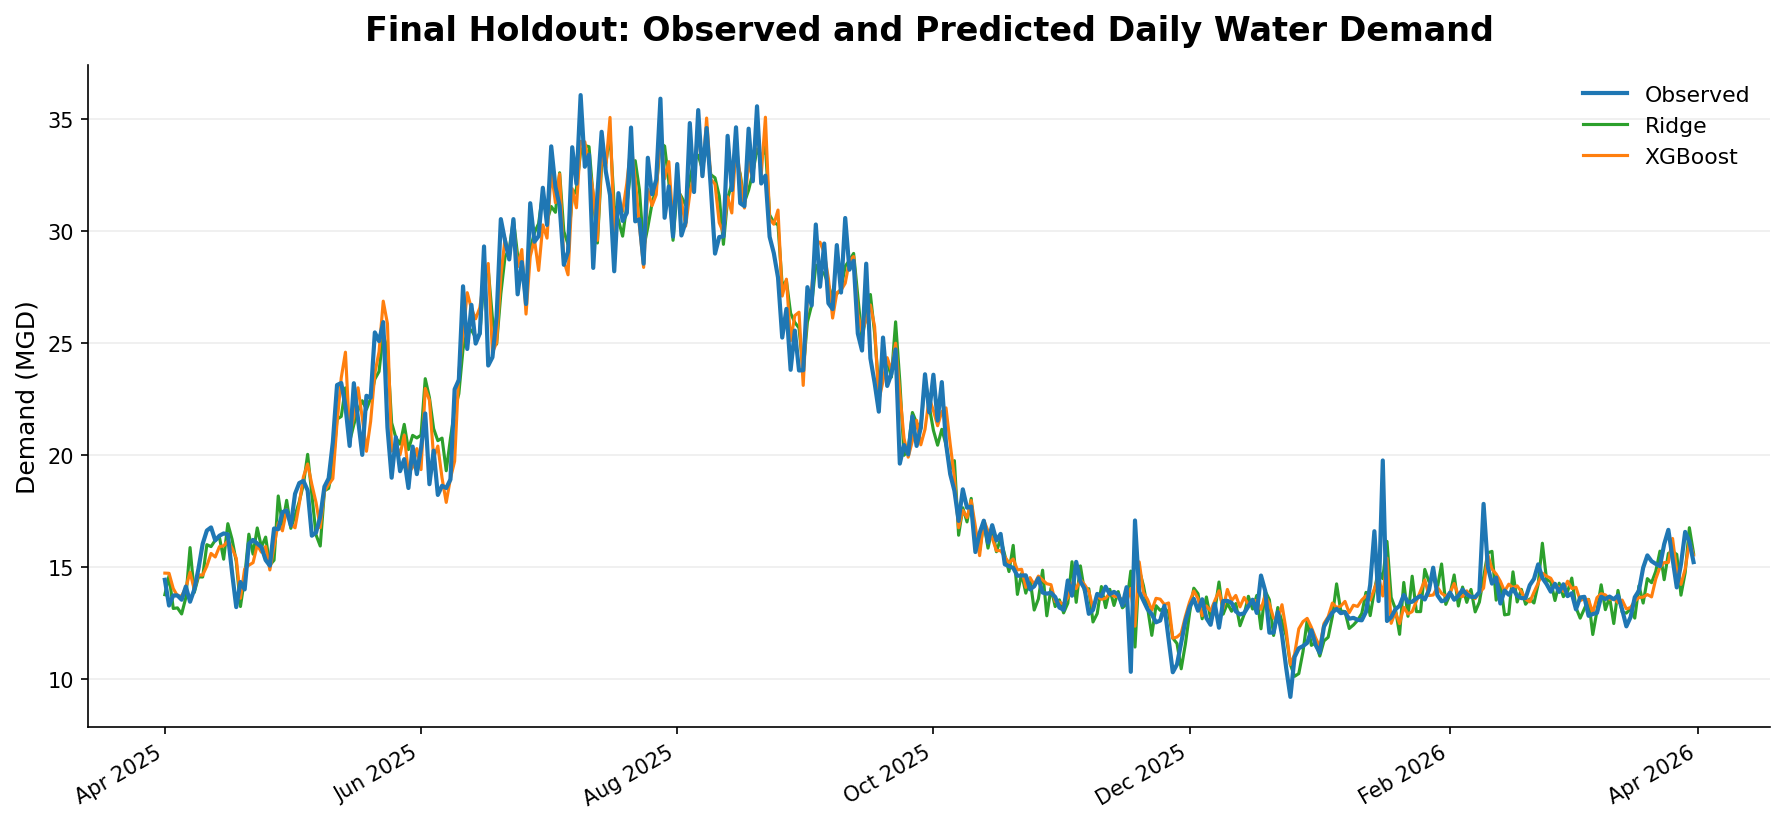

Saved: /content/municipal-water-demand-forecasting/reports/figures/final_holdout_observed_vs_predicted.png


In [41]:
OBSERVED_VS_PREDICTED_PATH = (
    FIGURE_DIR
    / "final_holdout_observed_vs_predicted.png"
)

plot_df = (
    holdout_predictions
    .sort_values("date")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(
    figsize=(12, 5.6),
    dpi=150,
)

# ---------------------------------------------------------
# Main lines
# ---------------------------------------------------------

ax.plot(
    plot_df["date"],
    plot_df["y_true"],
    label="Observed",
    color="tab:blue",
    linewidth=2,
    zorder=3,
)

ax.plot(
    plot_df["date"],
    plot_df["ridge_prediction"],
    label="Ridge",
    color="tab:green",
    linewidth=1.5,
    zorder=2,
)

ax.plot(
    plot_df["date"],
    plot_df["xgb_prediction"],
    label="XGBoost",
    color="tab:orange",
    linewidth=1.5,
    zorder=2,
)

# ---------------------------------------------------------
# Titles and labels
# ---------------------------------------------------------

ax.set_title(
    "Final Holdout: Observed and Predicted Daily Water Demand",
    fontsize=16,
    fontweight="semibold",
    pad=12,
)

ax.set_ylabel(
    "Demand (MGD)",
    fontsize=12,
)

ax.set_xlabel("")

# ---------------------------------------------------------
# Date-axis formatting
# ---------------------------------------------------------

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.setp(
    ax.get_xticklabels(),
    rotation=30,
    ha="right",
)

# ---------------------------------------------------------
# Grid and frame styling
# ---------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.22,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# ---------------------------------------------------------
# Legend
# ---------------------------------------------------------

ax.legend(
    loc="upper right",
    frameon=False,
    fontsize=10.5,
)

fig.tight_layout()

fig.savefig(
    OBSERVED_VS_PREDICTED_PATH,
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", OBSERVED_VS_PREDICTED_PATH)

## Final holdout MAE by demand-change magnitude

This figure groups holdout dates by the magnitude of the observed
day-to-day change in demand and compares model MAE within each group.
The groups are defined as quintiles of the absolute daily change.

In [42]:
import numpy as np

change_df = (
    holdout_predictions
    .copy()
    .sort_values("date")
    .reset_index(drop=True)
)

# Absolute day-to-day change in observed demand.
# For the holdout, previous_day_prediction is yesterday's observed demand.
change_df["change_magnitude"] = (
    change_df["y_true"] - change_df["previous_day_prediction"]
).abs()

# Use ranked values so qcut always produces five equally sized groups.
change_df["change_quintile"] = (
    pd.qcut(
        change_df["change_magnitude"].rank(method="first"),
        q=5,
        labels=[1, 2, 3, 4, 5],
    )
    .astype(int)
)

QUINTILE_LABELS = {
    1: "Q1\n(smallest changes)",
    2: "Q2",
    3: "Q3",
    4: "Q4",
    5: "Q5\n(largest changes)",
}

change_df["change_group"] = (
    change_df["change_quintile"]
    .map(QUINTILE_LABELS)
)

display(
    change_df[
        [
            "date",
            "y_true",
            "previous_day_prediction",
            "change_magnitude",
            "change_quintile",
            "change_group",
        ]
    ].head()
)

print(change_df["change_quintile"].value_counts().sort_index())

,date,y_true,previous_day_prediction,change_magnitude,change_quintile,change_group
0,2025-04-01,14.44,14.33,0.11,1,Q1\n(smallest changes)
1,2025-04-02,13.29,14.44,1.15,4,Q4
2,2025-04-03,13.74,13.29,0.45,2,Q2
3,2025-04-04,13.74,13.74,0.00,1,Q1\n(smallest changes)
4,2025-04-05,13.55,13.74,0.19,1,Q1\n(smallest changes)


change_quintile
1    73
2    73
3    73
4    73
5    73
Name: count, dtype: int64


In [43]:
quintile_mae = (
    change_df
    .groupby(
        ["change_quintile", "change_group"],
        as_index=False,
    )
    .agg(
        persistence_mae=("previous_day_absolute_error", "mean"),
        ridge_mae=("ridge_absolute_error", "mean"),
        xgb_mae=("xgb_absolute_error", "mean"),
        n_days=("date", "size"),
    )
    .sort_values("change_quintile")
    .reset_index(drop=True)
)

quintile_mae["xgb_skill_vs_persistence_pct"] = (
    100
    * (
        1
        - quintile_mae["xgb_mae"] / quintile_mae["persistence_mae"]
    )
)

display(quintile_mae)

,change_quintile,change_group,persistence_mae,ridge_mae,xgb_mae,n_days,xgb_skill_vs_persistence_pct
0,1,Q1\n(smallest changes),0.099041,0.525522,0.377192,73,-280.844109
1,2,Q2,0.372329,0.618641,0.471121,73,-26.533496
2,3,Q3,0.800822,0.850940,0.758755,73,5.252964
3,4,Q4,1.603151,0.958784,0.937940,73,41.493981
4,5,Q5\n(largest changes),3.546849,2.014721,1.836418,73,48.223977


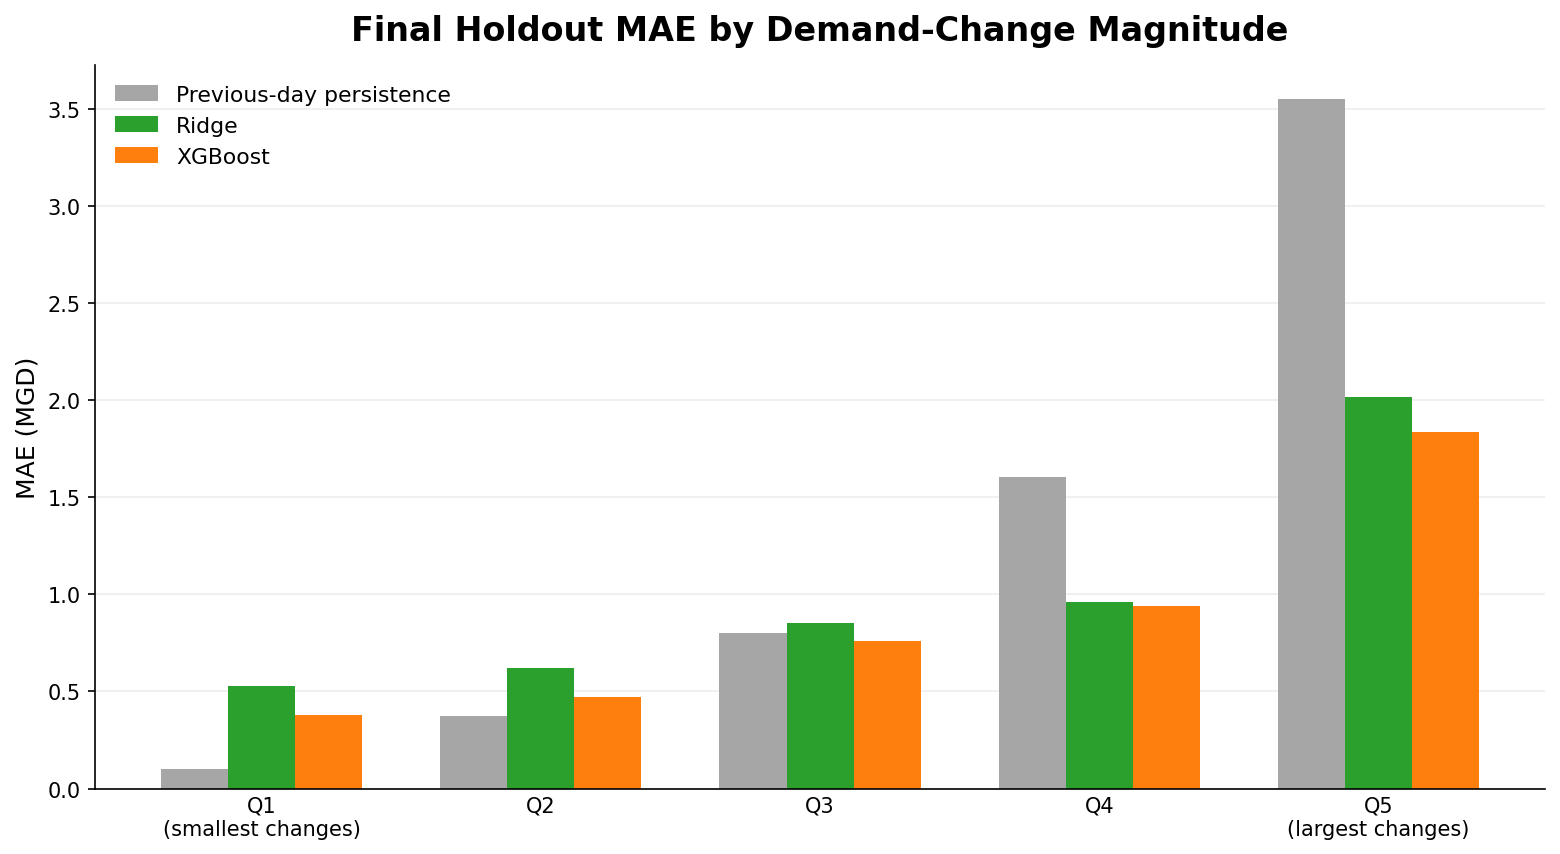

Saved: /content/municipal-water-demand-forecasting/reports/figures/final_holdout_mae_by_change_magnitude.png


In [44]:
CHANGE_MAGNITUDE_FIGURE_PATH = (
    FIGURE_DIR
    / "final_holdout_mae_by_change_magnitude.png"
)

x = np.arange(len(quintile_mae))
width = 0.24

fig, ax = plt.subplots(
    figsize=(10.5, 5.8),
    dpi=150,
)

ax.bar(
    x - width,
    quintile_mae["persistence_mae"],
    width=width,
    color="0.65",
    label="Previous-day persistence",
)

ax.bar(
    x,
    quintile_mae["ridge_mae"],
    width=width,
    color="tab:green",
    label="Ridge",
)

ax.bar(
    x + width,
    quintile_mae["xgb_mae"],
    width=width,
    color="tab:orange",
    label="XGBoost",
)

# ---------------------------------------------------------
# Titles and labels
# ---------------------------------------------------------

ax.set_title(
    "Final Holdout MAE by Demand-Change Magnitude",
    fontsize=16,
    fontweight="semibold",
    pad=12,
)

ax.set_ylabel(
    "MAE (MGD)",
    fontsize=12,
)

ax.set_xlabel("")

ax.set_xticks(x)
ax.set_xticklabels(
    quintile_mae["change_group"],
    fontsize=10,
)

# ---------------------------------------------------------
# Styling
# ---------------------------------------------------------

ax.grid(
    axis="y",
    alpha=0.22,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="y", labelsize=10)
ax.tick_params(axis="x", length=0)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=10.5,
)

fig.tight_layout()

fig.savefig(
    CHANGE_MAGNITUDE_FIGURE_PATH,
    dpi=150,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("Saved:", CHANGE_MAGNITUDE_FIGURE_PATH)